In [1]:
import re
import string
import numpy as np 
import random
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
from plotly import graph_objs as go
import plotly.express as px
import plotly.figure_factory as ff
from collections import Counter
import warnings
warnings.filterwarnings("ignore")
from transformers import logging
logging.set_verbosity_error()
import os
os.environ["TRANSFORMERS_NO_ADVISORY_WARNINGS"] = "true"
from PIL import Image
from wordcloud import WordCloud, STOPWORDS, ImageColorGenerator


import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

from tqdm import tqdm
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

import nltk
import spacy
import random
from spacy.util import compounding
from spacy.util import minibatch

from collections import defaultdict
from collections import Counter

import keras
from keras.models import Sequential
from keras.initializers import Constant
from keras.layers import (LSTM, 
                          Embedding, 
                          BatchNormalization,
                          Dense, 
                          TimeDistributed, 
                          Dropout, 
                          Bidirectional,
                          Flatten, 
                          GlobalMaxPool1D)
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.layers import Embedding
from keras.callbacks import ModelCheckpoint, ReduceLROnPlateau
from keras.optimizers import Adam

from sklearn.metrics import (
    precision_score, 
    recall_score, 
    f1_score, 
    classification_report,
    accuracy_score
)

/kaggle/input/datasets/muqaddasejaz/fake-reviews-dataset/fake reviews dataset.csv


2026-06-20 08:47:48.895185: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1781945269.169427      16 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1781945269.246681      16 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1781945269.857468      16 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1781945269.857546      16 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1781945269.857549      16 computation_placer.cc:177] computation placer alr

# ====================================================
#  1. Loading Data 
# ====================================================


In [2]:
df = pd.read_csv("/kaggle/input/datasets/muqaddasejaz/fake-reviews-dataset/fake reviews dataset.csv")

# ====================================================
# 2. Exploratory Data Analysis (EDA) + visualization
# ====================================================


In [3]:
df.head()

,category,rating,label,text_
0,Home_and_Kitchen_5,5.0,CG,"Love this! Well made, sturdy, and very comfor..."
1,Home_and_Kitchen_5,5.0,CG,"love it, a great upgrade from the original. I..."
2,Home_and_Kitchen_5,5.0,CG,This pillow saved my back. I love the look and...
3,Home_and_Kitchen_5,1.0,CG,"Missing information on how to use it, but it i..."
4,Home_and_Kitchen_5,5.0,CG,Very nice set. Good quality. We have had the s...


In [4]:
df.tail()

,category,rating,label,text_
40427,Clothing_Shoes_and_Jewelry_5,4.0,OR,I had read some reviews saying that this bra r...
40428,Clothing_Shoes_and_Jewelry_5,5.0,CG,I wasn't sure exactly what it would be. It is ...
40429,Clothing_Shoes_and_Jewelry_5,2.0,OR,"You can wear the hood by itself, wear it with ..."
40430,Clothing_Shoes_and_Jewelry_5,1.0,CG,I liked nothing about this dress. The only rea...
40431,Clothing_Shoes_and_Jewelry_5,5.0,OR,I work in the wedding industry and have to wor...


In [5]:
df.sample(10)

,category,rating,label,text_
9118,Electronics_5,5.0,CG,Very nice and high quality. I love the feel o...
39733,Clothing_Shoes_and_Jewelry_5,4.0,OR,I like the shoe but I should have gone 1 1/2 s...
37306,Clothing_Shoes_and_Jewelry_5,4.0,CG,These socks were really comfortable. I wear a...
7871,Sports_and_Outdoors_5,5.0,OR,OK...I have been carrying every known backpack...
23476,Pet_Supplies_5,4.0,CG,We've been really lucky that this has kept the...
4137,Sports_and_Outdoors_5,5.0,OR,Keeps the clubs nice and protected.
9731,Electronics_5,5.0,CG,I use the 32GB SanDisk Extreme HD and the 64GB...
18955,Tools_and_Home_Improvement_5,5.0,CG,Love this Moen 26100 Magnetix (Cordless) in th...
5920,Sports_and_Outdoors_5,5.0,OR,This saddle is so comfortable. Very soft. Keep...
35190,Toys_and_Games_5,5.0,CG,This is probably the most beautiful set I've e...


In [6]:
df.shape

(40432, 4)

In [7]:
df.columns

Index(['category', 'rating', 'label', 'text_'], dtype='object')

In [8]:
df.describe(include='all')

,category,rating,label,text_
count,40432,40432.000000,40432,40432
unique,10,NaN,2,40412
top,Kindle_Store_5,NaN,CG,My dog loves these and it has kept her occupie...
freq,4730,NaN,20216,2
mean,NaN,4.256579,NaN,NaN
std,NaN,1.144354,NaN,NaN
min,NaN,1.000000,NaN,NaN
25%,NaN,4.000000,NaN,NaN
50%,NaN,5.000000,NaN,NaN
75%,NaN,5.000000,NaN,NaN


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40432 entries, 0 to 40431
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   category  40432 non-null  object 
 1   rating    40432 non-null  float64
 2   label     40432 non-null  object 
 3   text_     40432 non-null  object 
dtypes: float64(1), object(3)
memory usage: 1.2+ MB


# Missing values 

In [10]:
print(" Null Values:")
print(df.isnull().sum())

 Null Values:
category    0
rating      0
label       0
text_       0
dtype: int64


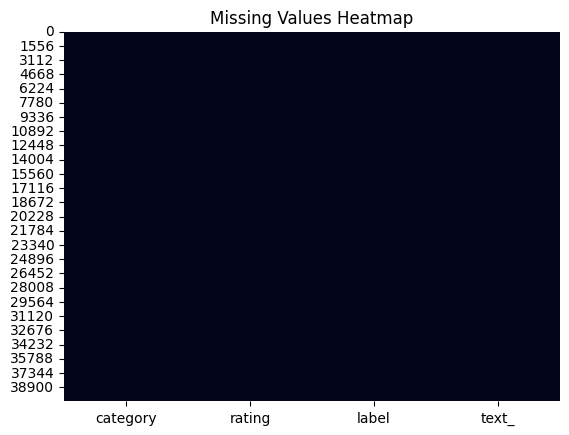

In [11]:
sns.heatmap(df.isnull(), cbar=False)
plt.title("Missing Values Heatmap")
plt.show()

 #  Data Types Distribution

In [12]:
df.dtypes

category     object
rating      float64
label        object
text_        object
dtype: object

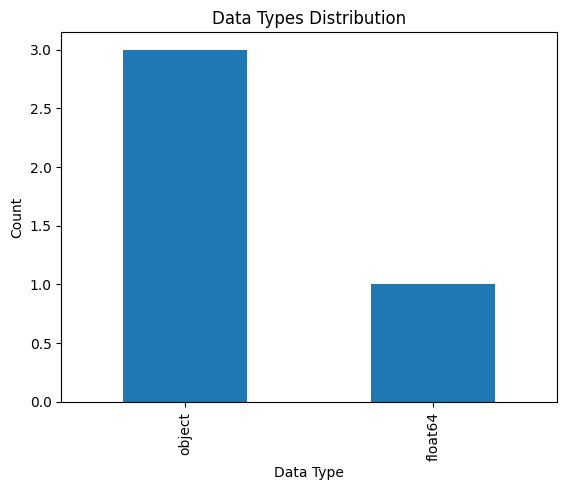

In [13]:
df.dtypes.value_counts().plot(kind='bar')
plt.title("Data Types Distribution")
plt.xlabel("Data Type")
plt.ylabel("Count")
plt.show()

In [14]:
print(df['label'].unique())

['CG' 'OR']


In [15]:
df.duplicated().sum()

np.int64(12)

In [16]:
df = df.drop_duplicates()

# Target Distribution (Imbalance Check)

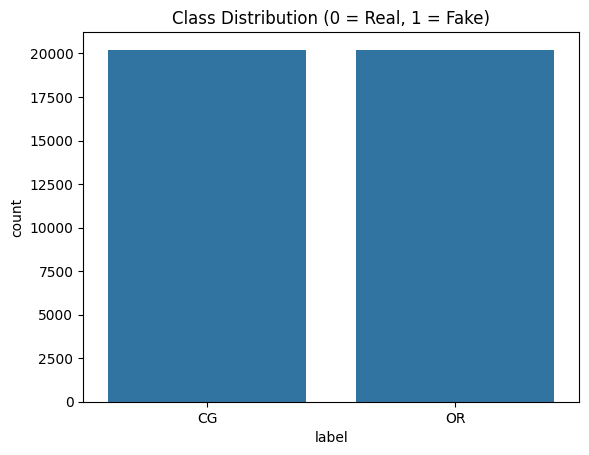

In [17]:
sns.countplot(x='label', data=df)
plt.title("Class Distribution (0 = Real, 1 = Fake)")
plt.show()

# Percentage of each class


In [18]:
df['label'].value_counts(normalize=True)

label
OR    0.500124
CG    0.499876
Name: proportion, dtype: float64

# Text Length

In [19]:
df['text_length'] = df['text_'].apply(len)

# Text Length Distribution

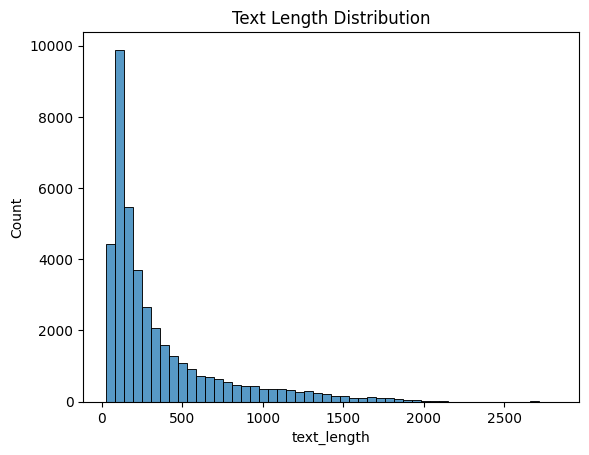

In [20]:
sns.histplot(df['text_length'], bins=50)
plt.title("Text Length Distribution")
plt.show()

# Outliers (Text Length)

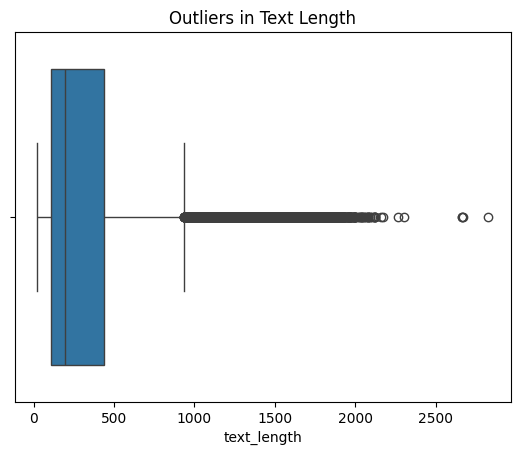

In [21]:
sns.boxplot(x=df['text_length'])
plt.title("Outliers in Text Length")
plt.show()

# Number of Words

In [22]:
df['word_count'] = df['text_'].apply(lambda x: len(str(x).split()))

# Word Count Distribution

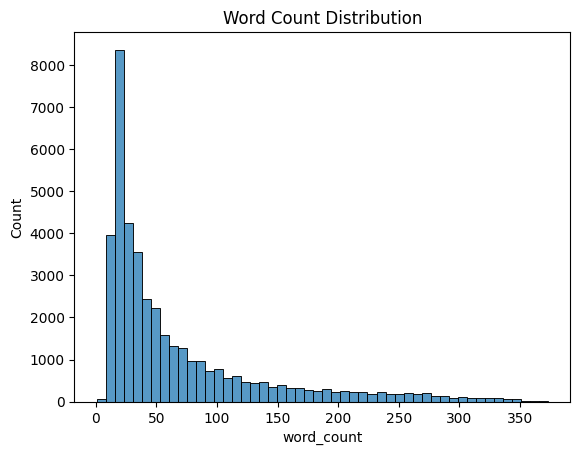

In [23]:
sns.histplot(df['word_count'], bins=50)
plt.title("Word Count Distribution")
plt.show()

# Rating vs Label

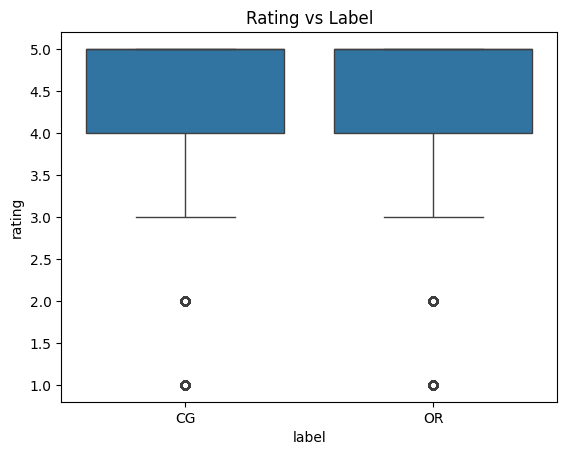

In [24]:
sns.boxplot(x='label', y='rating', data=df)
plt.title("Rating vs Label")
plt.show()

# Rating Distribution

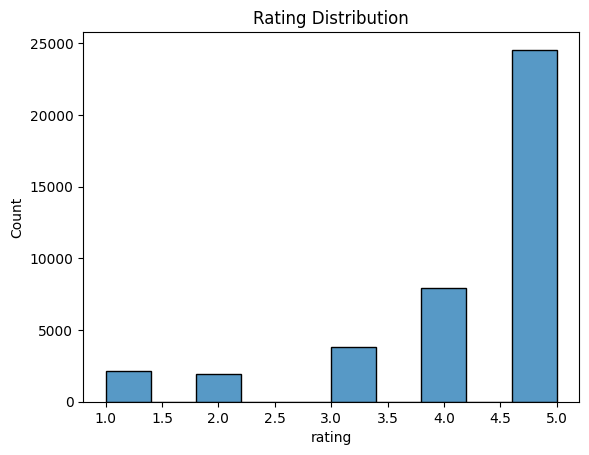

In [25]:
sns.histplot(df['rating'], bins=10)
plt.title("Rating Distribution")
plt.show()

# Category Distribution

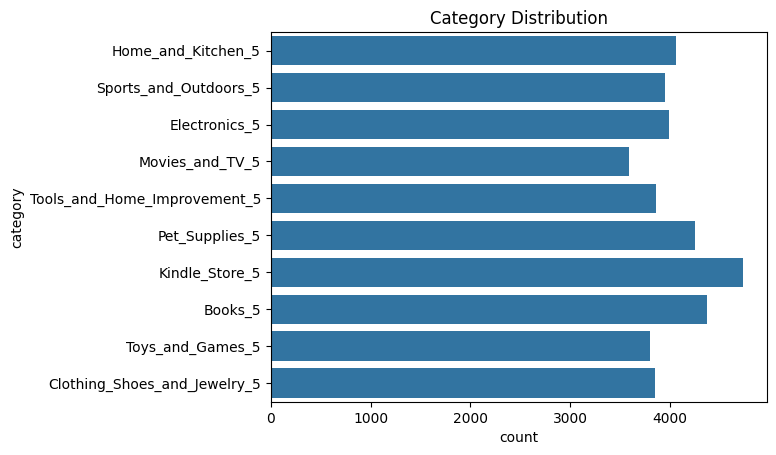

In [26]:
sns.countplot(y='category', data=df)
plt.title("Category Distribution")
plt.show()

# Average Word Length

In [27]:
df['avg_word_len'] = df['text_'].apply(lambda x: np.mean([len(word) for word in str(x).split()]))

# Check Empty or Very Short Texts

In [28]:
df['word_count'] = df['text_'].apply(lambda x: len(str(x).split()))
df[df['word_count'] < 3]

,category,rating,label,text_,text_length,word_count,avg_word_len
21686,Pet_Supplies_5,5.0,CG,Well............................................,48,1,48.0
37914,Clothing_Shoes_and_Jewelry_5,4.0,CG,. .,24,2,1.0


# Uppercase Ratio (Spam indicator)

In [29]:
df['upper_ratio'] = df['text_'].apply(lambda x: sum(1 for c in str(x) if c.isupper()) / len(str(x)))

# Special Characters Count

In [30]:
df['special_chars'] = df['text_'].apply(lambda x: len([c for c in str(x) if c in string.punctuation]))

# URLs Detection

In [31]:
df['has_url'] = df['text_'].apply(lambda x: bool(re.search(r'http\S+', str(x))))
df['has_url'].value_counts()

has_url
False    40313
True       107
Name: count, dtype: int64

# Stopwords Ratio

In [32]:
from nltk.corpus import stopwords
stop_words = set(stopwords.words('english'))

df['stopword_ratio'] = df['text_'].apply(
    lambda x: len([w for w in str(x).lower().split() if w in stop_words]) / len(str(x).split())
)

# Most Common Words

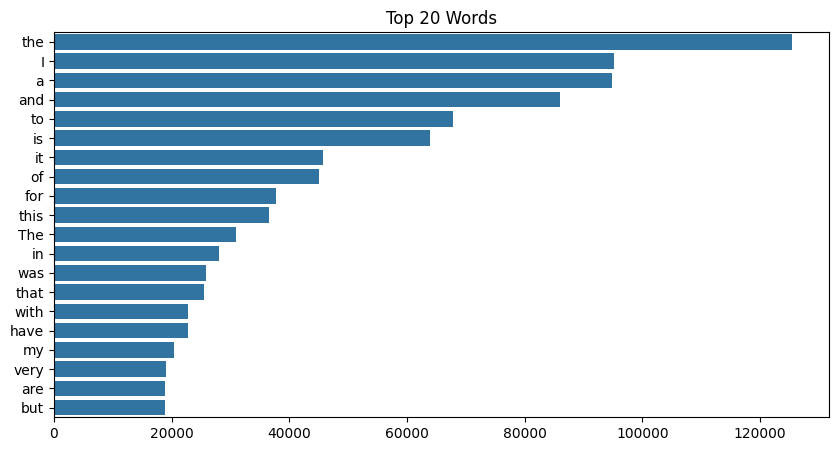

In [33]:
all_words = " ".join(df['text_']).split()
common_words = Counter(all_words).most_common(20)

words, counts = zip(*common_words)

plt.figure(figsize=(10,5))
sns.barplot(x=list(counts), y=list(words))
plt.title("Top 20 Words")
plt.show()

# WordCloud

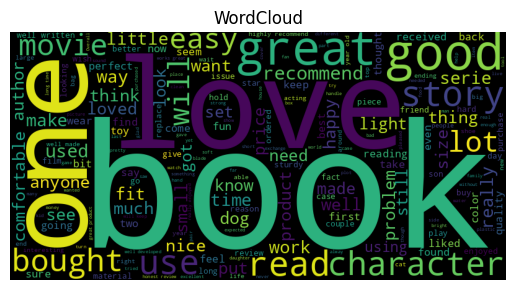

In [34]:
from wordcloud import WordCloud

wordcloud = WordCloud(width=800, height=400).generate(" ".join(df['text_']))

plt.imshow(wordcloud)
plt.axis("off")
plt.title("WordCloud")
plt.show()

# ====================================================
# 3. Preprocessing + Data Cleaning
# ====================================================

# One-Hot Encoding for category

In [35]:
df = pd.get_dummies(df, columns=['category'], drop_first=True)

# StandardScaler

In [36]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

df['rating_scaled'] = scaler.fit_transform(df[['rating']])

# Encoding for label

In [37]:
df['label'].unique()

array(['CG', 'OR'], dtype=object)

In [38]:
df['label'] = df['label'].map({'CG': 1, 'OR': 0})

In [39]:
print(df['label'].value_counts())
print(df['label'].isna().sum())

label
0    20215
1    20205
Name: count, dtype: int64
0


In [40]:
def clean_text(text):
    text = str(text).lower()
    
    # remove urls
    text = re.sub(r'http\S+|www\S+', '', text)
    
    # remove repeated dots or punctuation
    text = re.sub(r'\.+', ' ', text)
    
    # remove numbers
    text = re.sub(r'\d+', '', text)
    
    # remove punctuation
    text = text.translate(str.maketrans('', '', string.punctuation))
    
    # remove extra spaces
    text = re.sub(r'\s+', ' ', text).strip()
    
    return text

# Apply Cleaning

In [41]:
df['clean_text'] = df['text_'].apply(clean_text)

In [42]:
df['label'].isnull().sum()

np.int64(0)

In [43]:
df['label'].unique()

array([1, 0])

In [44]:
# هيعرفك كل عمود فيه كام قيمة فاضية
print(df.isnull().sum())

# هيعرفك نسبة المفقود في كل عمود (مهمة جداً عشان تاخد قرار)
print((df.isnull().sum() / len(df)) * 100)

rating                                   0
label                                    0
text_                                    0
text_length                              0
word_count                               0
avg_word_len                             0
upper_ratio                              0
special_chars                            0
has_url                                  0
stopword_ratio                           0
category_Clothing_Shoes_and_Jewelry_5    0
category_Electronics_5                   0
category_Home_and_Kitchen_5              0
category_Kindle_Store_5                  0
category_Movies_and_TV_5                 0
category_Pet_Supplies_5                  0
category_Sports_and_Outdoors_5           0
category_Tools_and_Home_Improvement_5    0
category_Toys_and_Games_5                0
rating_scaled                            0
clean_text                               0
dtype: int64
rating                                   0.0
label                                  

# Feature Engineering (Basic NLP Features)

In [45]:
df['word_count'] = df['clean_text'].apply(lambda x: len(x.split()))
df['char_count'] = df['clean_text'].apply(len)
df['avg_word_len'] = df['clean_text'].apply(lambda x: np.mean([len(w) for w in x.split()]) if len(x.split()) > 0 else 0)

# Remove outliers

In [46]:
df = df[df['word_count'] < df['word_count'].quantile(0.99)]

# Basic Numerical Features

In [47]:
df['word_count'] = df['clean_text'].apply(lambda x: len(x.split()))
df['char_count'] = df['clean_text'].apply(len)
df['avg_word_len'] = df['clean_text'].apply(
    lambda x: np.mean([len(w) for w in x.split()]) if len(x.split()) > 0 else 0
)

# Sentiment-like Features

In [48]:
df['exclamation_count'] = df['text_'].apply(lambda x: str(x).count('!'))
df['question_count'] = df['text_'].apply(lambda x: str(x).count('?'))

# Capitalization Feature (spam indicator)

In [49]:
df['upper_ratio'] = df['text_'].apply(
    lambda x: sum(1 for c in str(x) if c.isupper()) / len(str(x)) if len(str(x)) > 0 else 0
)

# Special Noise Features

In [50]:
import re

df['has_url'] = df['text_'].apply(lambda x: bool(re.search(r'http\S+', str(x))))
df['dot_ratio'] = df['text_'].apply(lambda x: str(x).count('.') / len(str(x)) if len(str(x)) > 0 else 0)

# ====================================================
# 4. Data Splitting
# ====================================================

In [51]:
X = df['clean_text']
y = df['label']

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# **(TF-IDF)**

In [52]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    stop_words='english',
    max_features=5000,
    ngram_range=(1,2)  # unigram + bigram
)

X_tfidf = tfidf.fit_transform(df['clean_text'])

# Combine Everything (Feature Matrix)

In [53]:
from scipy.sparse import hstack

extra_features = df[['word_count', 'char_count', 'avg_word_len', 'upper_ratio']]

X_final = hstack([X_tfidf, extra_features])
y = df['label']

In [54]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(stop_words='english', max_features=5000, ngram_range=(1,2))

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

In [55]:
df.to_csv('cleaned_data.csv', index=False)

# ====================================================
# 5. Modeling
# ====================================================

# Logistic Regression 

In [56]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)
model.fit(X_train_tfidf, y_train)

LogisticRegression(max_iter=1000)

In [57]:
y_pred = model.predict(X_test_tfidf)

In [58]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("Accuracy:", accuracy_score(y_test, y_pred))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:\n")
print(confusion_matrix(y_test, y_pred))

Accuracy: 0.882918905410471

Classification Report:

              precision    recall  f1-score   support

           0       0.87      0.89      0.88      3963
           1       0.89      0.87      0.88      4040

    accuracy                           0.88      8003
   macro avg       0.88      0.88      0.88      8003
weighted avg       0.88      0.88      0.88      8003


Confusion Matrix:

[[3545  418]
 [ 519 3521]]


# xgboost

In [59]:
pip install xgboost

Note: you may need to restart the kernel to use updated packages.


In [60]:

from xgboost import XGBClassifier
xgb_resampled = XGBClassifier(n_estimators=100, learning_rate=0.1, random_state=42, eval_metric='logloss')
xgb_resampled.fit(X_train_tfidf, y_train)
y_pred_xgb_resampled = xgb_resampled.predict(X_test_tfidf)

print("Confusion Matrix (XGBoost - Resampled):")
print(confusion_matrix(y_test, y_pred_xgb_resampled))
print(classification_report(y_test, y_pred_xgb_resampled))
print("Accuracy:", accuracy_score(y_test, y_pred))

Confusion Matrix (XGBoost - Resampled):
[[3513  450]
 [1168 2872]]
              precision    recall  f1-score   support

           0       0.75      0.89      0.81      3963
           1       0.86      0.71      0.78      4040

    accuracy                           0.80      8003
   macro avg       0.81      0.80      0.80      8003
weighted avg       0.81      0.80      0.80      8003

Accuracy: 0.882918905410471


# Decision Tree Classifier

In [61]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train_tfidf, y_train)

y_pred_dt = dt_model.predict(X_test_tfidf)

print("Decision Tree Results")
print(confusion_matrix(y_test, y_pred_dt))
print(classification_report(y_test, y_pred_dt))
print("Accuracy:", accuracy_score(y_test, y_pred_dt))

Decision Tree Results
[[2944 1019]
 [1053 2987]]
              precision    recall  f1-score   support

           0       0.74      0.74      0.74      3963
           1       0.75      0.74      0.74      4040

    accuracy                           0.74      8003
   macro avg       0.74      0.74      0.74      8003
weighted avg       0.74      0.74      0.74      8003

Accuracy: 0.741097088591778


# Random Forest Classifier

In [62]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train_tfidf, y_train)

y_pred_rf = rf_model.predict(X_test_tfidf)

print("Random Forest Results")
print(confusion_matrix(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))
print("Accuracy:", accuracy_score(y_test, y_pred_rf))

Random Forest Results
[[3458  505]
 [ 671 3369]]
              precision    recall  f1-score   support

           0       0.84      0.87      0.85      3963
           1       0.87      0.83      0.85      4040

    accuracy                           0.85      8003
   macro avg       0.85      0.85      0.85      8003
weighted avg       0.85      0.85      0.85      8003

Accuracy: 0.8530551043358741


# KNeighbors Classifier

In [63]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train_tfidf, y_train)

y_pred_knn = knn_model.predict(X_test_tfidf)

print("KNN Results")
print(confusion_matrix(y_test, y_pred_knn))
print(classification_report(y_test, y_pred_knn))
print("Accuracy:", accuracy_score(y_test, y_pred_knn))

KNN Results
[[ 369 3594]
 [ 206 3834]]
              precision    recall  f1-score   support

           0       0.64      0.09      0.16      3963
           1       0.52      0.95      0.67      4040

    accuracy                           0.53      8003
   macro avg       0.58      0.52      0.42      8003
weighted avg       0.58      0.53      0.42      8003

Accuracy: 0.5251780582281644


# SVC

In [64]:
from sklearn.svm import SVC
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

svm_model = SVC(kernel='rbf')
svm_model.fit(X_train_tfidf, y_train)

y_pred_svm = svm_model.predict(X_test_tfidf)

print("SVM Results")
print(confusion_matrix(y_test, y_pred_svm))
print(classification_report(y_test, y_pred_svm))
print("Accuracy:", accuracy_score(y_test, y_pred_svm))

SVM Results
[[3634  329]
 [ 532 3508]]
              precision    recall  f1-score   support

           0       0.87      0.92      0.89      3963
           1       0.91      0.87      0.89      4040

    accuracy                           0.89      8003
   macro avg       0.89      0.89      0.89      8003
weighted avg       0.89      0.89      0.89      8003

Accuracy: 0.8924153442459077


# MODEL  COMPARISON

📊 Model Comparison:

                 Model  Accuracy  Recall  F1-score
5                  SVM    0.8931    0.89      0.89
0  Logistic Regression    0.8825    0.88      0.88
3        Random Forest    0.8541    0.85      0.85
1              XGBoost    0.7900    0.80      0.78
2        Decision Tree    0.7419    0.74      0.74
4                  KNN    0.5226    0.52      0.41

🏆 Best Model:
Model          SVM
Accuracy    0.8931
Recall        0.89
F1-score      0.89
Name: 5, dtype: object


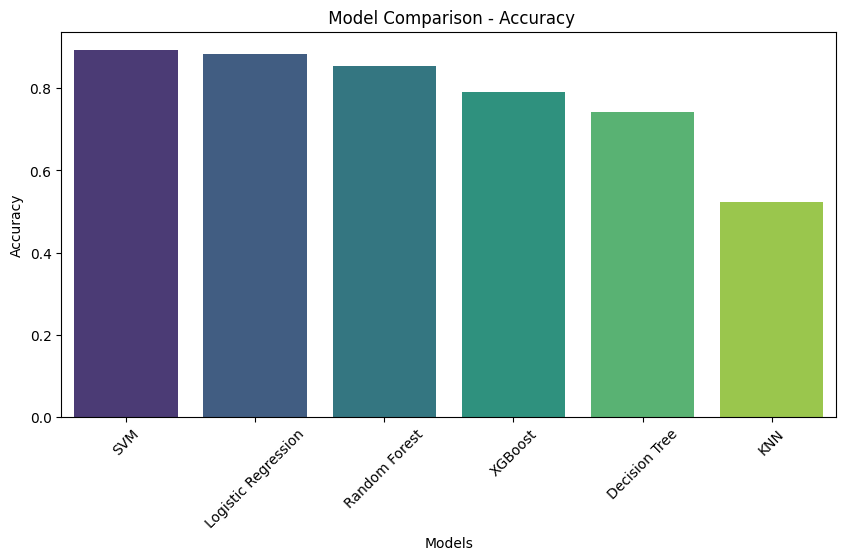

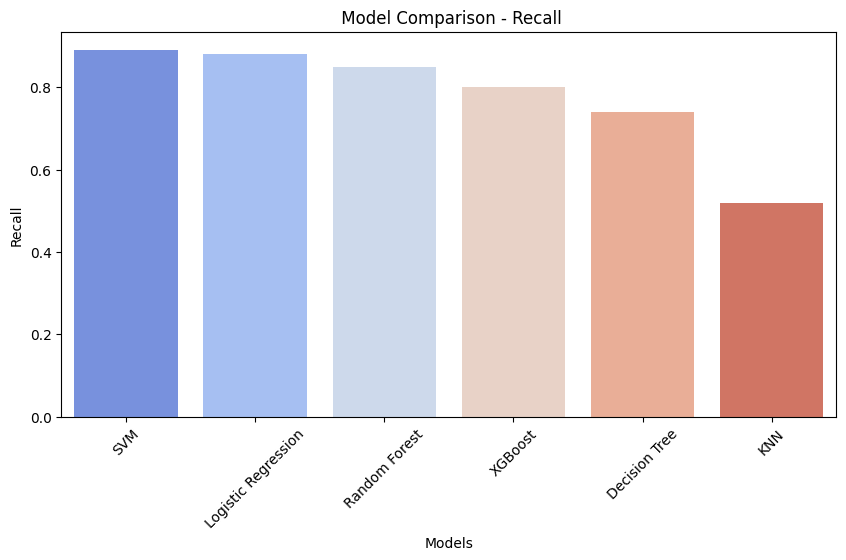

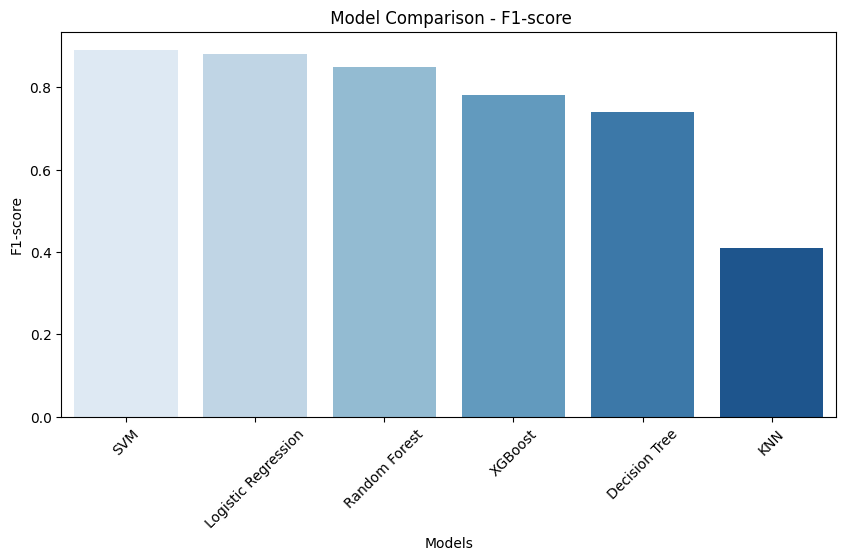

In [65]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# =========================
# Data
# =========================
results = [
    {'Model': 'Logistic Regression', 'Accuracy': 0.8825, 'Recall': 0.88, 'F1-score': 0.88},
    {'Model': 'XGBoost', 'Accuracy': 0.79, 'Recall': 0.80, 'F1-score': 0.78},
    {'Model': 'Decision Tree', 'Accuracy': 0.7419, 'Recall': 0.74, 'F1-score': 0.74},
    {'Model': 'Random Forest', 'Accuracy': 0.8541, 'Recall': 0.85, 'F1-score': 0.85},
    {'Model': 'KNN', 'Accuracy': 0.5226, 'Recall': 0.52, 'F1-score': 0.41},
    {'Model': 'SVM', 'Accuracy': 0.8931, 'Recall': 0.89, 'F1-score': 0.89}
]
df_results = pd.DataFrame(results)

# =========================
# Sorting (Best model first)
# =========================
df_results = df_results.sort_values(by='F1-score', ascending=False)

print("📊 Model Comparison:\n")
print(df_results)

# =========================
# Best Model
# =========================
best_model = df_results.iloc[0]

print("\n🏆 Best Model:")
print(best_model)


df = pd.DataFrame(results)

# =========================
# Sort by F1-score (best overall)
# =========================
df = df.sort_values(by='F1-score', ascending=False)

# =========================
# 1️⃣ Accuracy Plot
# =========================
plt.figure(figsize=(10,5))
sns.barplot(data=df, x='Model', y='Accuracy', palette='viridis')
plt.xticks(rotation=45)
plt.title(" Model Comparison - Accuracy")
plt.xlabel("Models")
plt.ylabel("Accuracy")
plt.show()

# =========================
# 2️⃣ Recall Plot
# =========================
plt.figure(figsize=(10,5))
sns.barplot(data=df, x='Model', y='Recall', palette='coolwarm')
plt.xticks(rotation=45)
plt.title(" Model Comparison - Recall")
plt.xlabel("Models")
plt.ylabel("Recall")
plt.show()

# =========================
# 3️⃣ F1-score Plot
# =========================
plt.figure(figsize=(10,5))
sns.barplot(data=df, x='Model', y='F1-score', palette='Blues')
plt.xticks(rotation=45)
plt.title(" Model Comparison - F1-score")
plt.xlabel("Models")
plt.ylabel("F1-score")
plt.show()

# Misclassified Samples Analysis

In [66]:
import pandas as pd

df_results = pd.DataFrame({
    'text': X_test,
    'true': y_test,
    'pred': y_pred
})

df_results[df_results['true'] != df_results['pred']].head(10)

,text,true,pred
4114,lights are great but the mounts are a bit flimsy,0,1
17898,we lost the original remote control the only r...,1,0
12072,loved it thoroughly a definite must watch high...,1,0
4130,very good quality i am glad i bought these,0,1
22379,i bought one for both my dogs the dogs love th...,0,1
32987,my daughter loves peppa after a wile the paint...,0,1
28821,one of the very best i have ever read on the m...,0,1
27423,king hall is the first book in this paranormal...,0,1
28640,pretty well written and action packed a good r...,0,1
16445,it is what it says and it is the two buttons a...,1,0


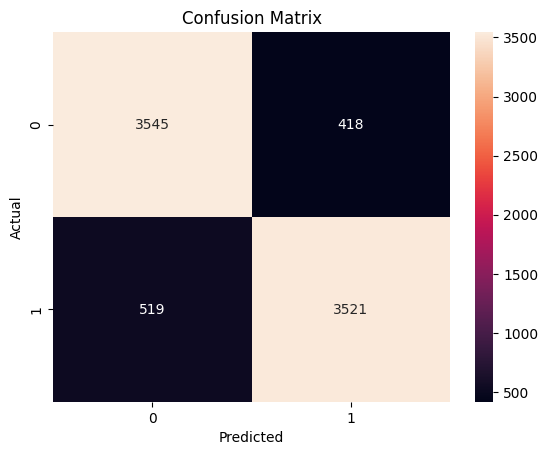

In [67]:
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()